In [1]:
import numpy as np
from scipy.stats import poisson
from scipy.optimize import Bounds, minimize, minimize_scalar
from itertools import permutations
from utilities import adaptive_util_poisson, nonadaptive_util_poisson
from tqdm.notebook import tqdm

import plotnine
from plotnine import (
    ggplot,
    aes, 
    geom_point, 
    geom_raster, 
    scale_x_continuous, 
    scale_y_continuous, 
    geom_abline, geom_vline, 
    geom_tile,
    geom_polygon, theme_void
)
import pandas as pd

In [2]:
n: int = 10
k: int = int(0.8 * n)

# Single Parameter

In [3]:
def f(eps):
    rv = poisson([int(0.5*n), int(eps*n), int((0.5 - eps)*n)])
    return min([1 / nonadaptive_util_poisson(rv, n, order, k) for order in permutations([0,1,2])])

In [4]:
minimize_scalar(f, bounds=[0.0, 0.5])

 message: Solution found.
 success: True
  status: 0
     fun: 1.5379977546628913
       x: 0.30902145932636804
     nit: 24
    nfev: 24

In [5]:
def plot_fn(eps):
    rv = poisson([int(0.5*n), int(eps*n), int((0.5 - eps)*n)])
    return max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations([0,1,2])])

In [6]:
xs = np.arange(0, 0.51, 0.01)
ys = [plot_fn(eps) for eps in xs]
df = pd.DataFrame([xs,ys]).T
df.columns = ['Epsilon', 'Util']

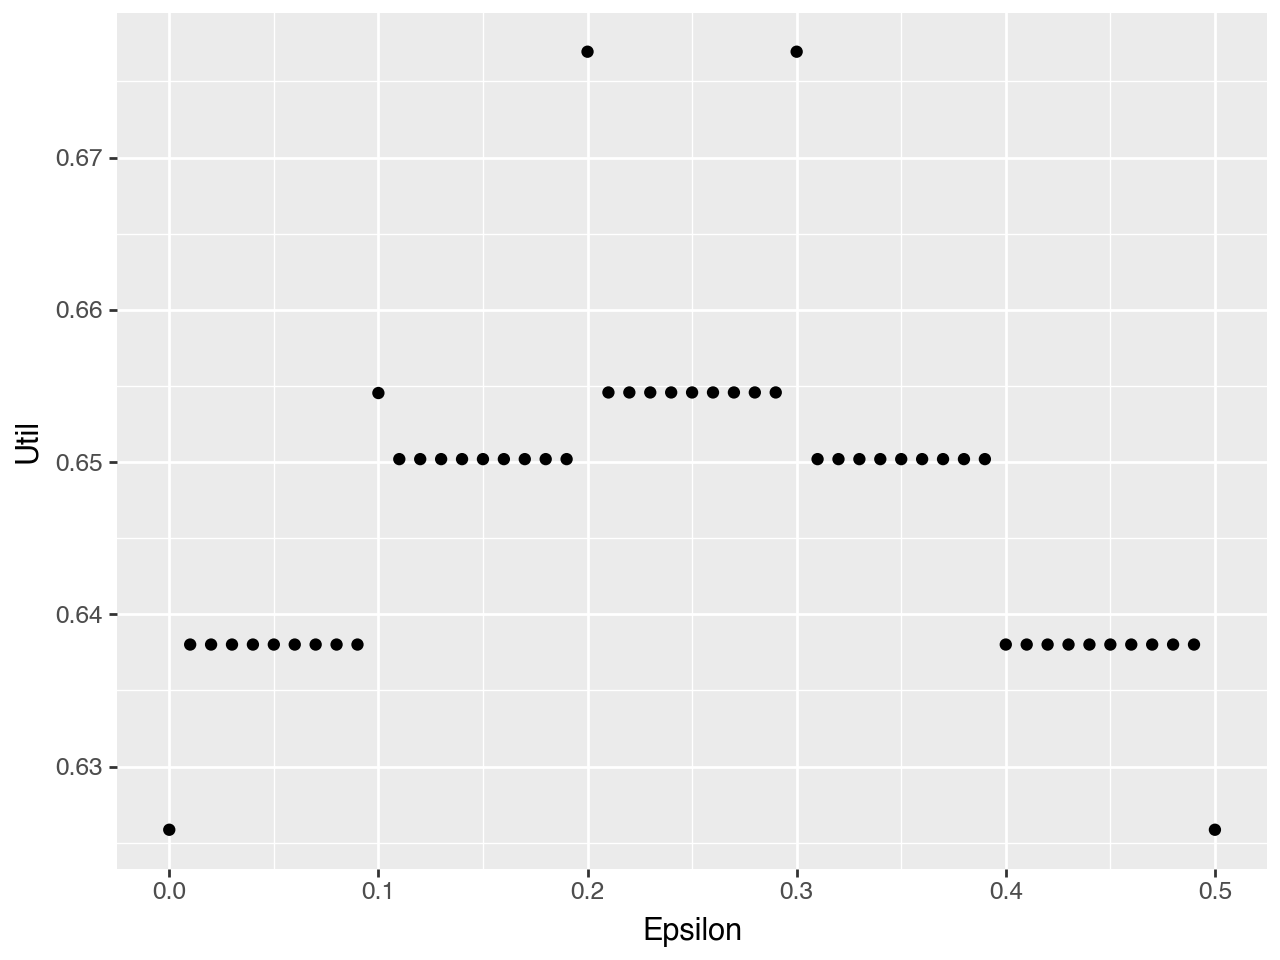

In [7]:
ggplot(data=df, mapping=aes(x='Epsilon',y='Util')) + geom_point()

In [8]:
def adaptivity_gap(eps):
    rv = poisson([int(0.5*n), int(eps*n), int((0.5 - eps)*n)])
    max_nonadaptive = max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations([0,1,2])])
    max_adaptive = max([max([adaptive_util_poisson(rv, n, order, k, t) for t in range(k)]) for order in permutations([0,1,2])])
    return max_nonadaptive / max_adaptive

In [9]:
minimize_scalar(adaptivity_gap, bounds=[0.05, 0.5])

 message: Solution found.
 success: True
  status: 0
     fun: 0.9989357809995592
       x: 0.32812097632522996
     nit: 22
    nfev: 22

In [10]:
1 / 0.97535892917503

1.0252635928045604

In [11]:
def adaptivity_gap_plot(eps):
    rv = poisson([int(0.5*n), int(eps*n), int((0.5 - eps)*n)])
    max_nonadaptive = max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations([0,1,2])])
    max_adaptive = max([max([adaptive_util_poisson(rv, n, order, k, t) for t in range(k)]) for order in permutations([0,1,2])])
    return max_adaptive/max_nonadaptive

In [12]:
xs = np.arange(0, 0.51, 0.01)
ys = [adaptivity_gap_plot(eps) for eps in xs]
df = pd.DataFrame([xs,ys]).T
df.columns = ['Epsilon', 'Adaptivity Gap']

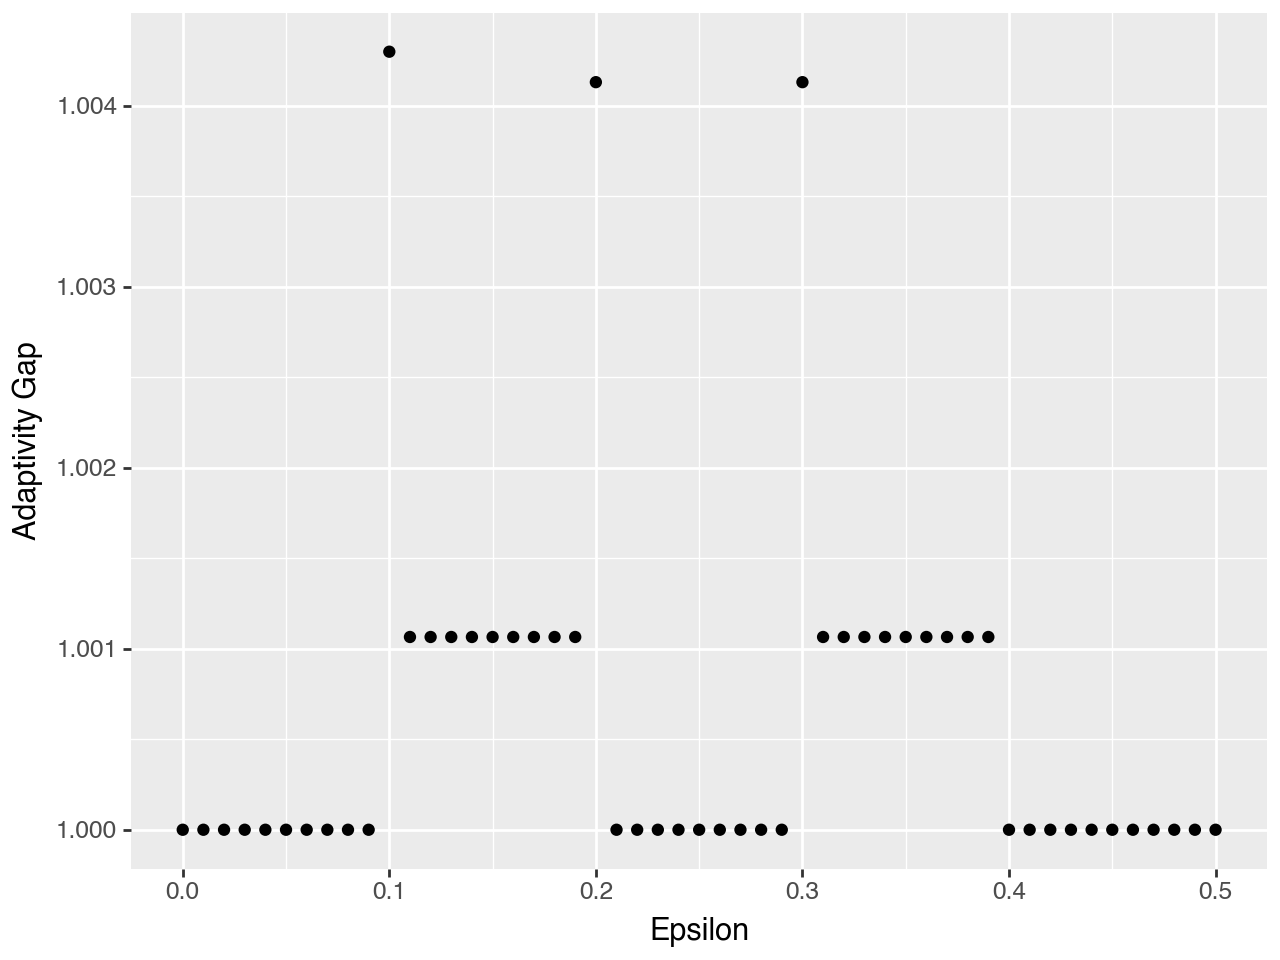

In [13]:
ggplot(data=df, mapping=aes(x='Epsilon',y='Adaptivity Gap')) + geom_point()

# Multi Parameter

In [14]:
def f(X):
    # rv = multinomial(n, np.array([X[0], X[1], X[2]])/sum(X))
    rv = poisson([n*i for i in X])
    return max([1 / nonadaptive_util_poisson(rv, n, order, k) for order in permutations([0,1,2])])

In [15]:
bounds = Bounds([0,0,0],[1,1,1])
minimize(f, [0.34, 0.33, 0.33], method='l-bfgs-b', bounds=bounds)

  message: ABNORMAL: 
  success: False
   status: 2
      fun: 1.4860927834169422
        x: [ 3.719e-01  3.689e-01  3.689e-01]
      nit: 4
      jac: [ 1.631e-01  1.106e-01  1.106e-01]
     nfev: 304
     njev: 76
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [16]:
nonadaptive_util_poissons = []
for a in np.arange(0, 1.01, 0.02):
    for b in np.arange(0, 1.01-a, 0.02):
        c = 1 - a - b
        rv = poisson([n*i for i in [a,b,c]])
        nonadaptive_util_poissons.append(((max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations(range(3))])),(a,b,c)))
max(nonadaptive_util_poissons, key=lambda x: x[0])

(np.float64(0.6810514900220077),
 (np.float64(0.26), np.float64(0.28), np.float64(0.45999999999999996)))

In [17]:
def adaptivity_gap_poisson(n: int, k: int, p: list[float]) -> float:
    rv = poisson([n*i for i in p])
    max_nonadaptive: float = max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations(range(3))])
    max_adaptive: float = max([max([adaptive_util_poisson(rv, n, order, k, t) for t in range(k)]) for order in permutations(range(3))])
    return max_adaptive / max_nonadaptive

In [18]:
# adaptive_util_poissons = []
# for a in np.arange(0, 1.01, 0.01):
#     for b in np.arange(0, 1.01-a, 0.01):
#         c = 1 - a - b
#         adaptive_util_poissons.append(adaptivity_gap([a,b,c]))
# np.nanmax(adaptive_util_poissons)

In [19]:
# np.nanmax(np.array(adaptive_util_poissons))

In [20]:
# np.nanmax(np.array(adaptive_util_poissons))

In [21]:
# adaptivity_gap([0.5, 0.17, 0.33])

In [22]:
max_gap = 0
for a in np.arange(0, 1.01, 0.04):
    for b in np.arange(0, 1.01-a, 0.04):
        c = 1 - a - b
        gap = adaptivity_gap_poisson(n, k, [a,b,c])
        if gap > max_gap:
            max_gap = gap 
            print(a,b,c)
            print(gap)

0.0 0.0 1.0
1.0
0.0 0.2 0.8
1.0000000000000002
0.04 0.4 0.5599999999999999
1.000171101996548
0.04 0.44 0.52
1.0004850112243069
0.04 0.48 0.48
1.0006664073449105
0.08 0.32 0.6000000000000001
1.0009826108700532
0.08 0.36 0.56
1.0016488243014197
0.08 0.4 0.52
1.0020908760900555
0.08 0.44 0.48000000000000004
1.0033353700743508
0.12 0.36 0.52
1.0045102847964826
0.12 0.4 0.48
1.006218077627039
0.12 0.44 0.44
1.0072762811018243
0.16 0.4 0.43999999999999995
1.0087416874466701
0.2 0.4 0.4
1.0111497061574861


In [23]:
for order in permutations([0,1,2]):
    print(order)
    print(adaptive_util_poisson(poisson([0,0,10]), 10, order, 8, 5))
    print(nonadaptive_util_poisson(poisson([0,0,10]), 10, order, 8))
    print()

(0, 1, 2)
0.3327742788209568
0.3327742788209568

(0, 2, 1)
0.3327742788209568
0.3327742788209568

(1, 0, 2)
0.3327742788209568
0.3327742788209568

(1, 2, 0)
0.3327742788209568
0.3327742788209568

(2, 0, 1)
0.3327742788209566
0.3327742788209566

(2, 1, 0)
0.3327742788209566
0.3327742788209566



In [24]:
max_gap = 0
for a in np.arange(0.14, 0.15, 0.001):
    for b in np.arange(0.41, 0.42, 0.001):
        c = 1 - a - b
        gap = adaptivity_gap_poisson(n, k, [a,b,c])
        if gap > max_gap:
            max_gap = gap 
            print(a,b,c)
            print(gap)

0.14 0.41 0.45
1.0078219389878587
0.14 0.411 0.449
1.0078467530348731
0.14 0.412 0.448
1.007871038344324
0.14 0.413 0.447
1.007894792659083
0.14 0.414 0.446
1.0079180137915738
0.14 0.415 0.445
1.0079406996239306
0.14 0.416 0.444
1.0079628481081564
0.14 0.417 0.443
1.0079844572662728
0.14 0.418 0.442
1.0080055251904638
0.14 0.419 0.441
1.0080260500432163
0.14 0.42 0.44
1.008046030057451
0.14100000000000001 0.418 0.441
1.0080488952230668
0.14100000000000001 0.419 0.44
1.008069053469491
0.14100000000000001 0.42 0.439
1.0080886635870137
0.14200000000000002 0.418 0.44
1.0080905883487696
0.14200000000000002 0.419 0.439
1.008110378344861
0.14200000000000002 0.42 0.438
1.0081296169845986
0.14300000000000002 0.418 0.439
1.008130607782849
0.14300000000000002 0.419 0.438
1.0081827393579563
0.14300000000000002 0.42 0.437
1.008254710144434
0.14400000000000002 0.419 0.437
1.0083131234929859
0.14400000000000002 0.42 0.436
1.0083849251176717
0.14500000000000002 0.419 0.436
1.008441595717859
0.14500000

In [25]:
adaptivity_gap_poisson(n, k, [0.145, 0.418, 0.437])

np.float64(1.008369534486323)

In [26]:
grid = []
step = 0.01
for a in tqdm(np.arange(0.0, 1.01, step)):
    row = []
    for b in np.arange(0.0, 1.01, step):
        c = 1 - a - b
        if c < 0:
            gap = np.nan 
        else:
            gap = adaptivity_gap_poisson(n, k, [a,b,c])
        row.append(gap)
    grid.append(row)

  0%|          | 0/101 [00:00<?, ?it/s]

In [27]:
grid_df = pd.DataFrame(grid).melt()
grid_df.columns = ['p_1', 'Gap']
grid_df.insert(1,'p_2',grid_df.index%len(grid))
grid_df

,p_1,p_2,Gap
0,0,0,1.0
1,0,1,1.0
2,0,2,1.0
3,0,3,1.0
4,0,4,1.0
...,...,...,...
10196,100,96,NaN
10197,100,97,NaN
10198,100,98,NaN
10199,100,99,NaN


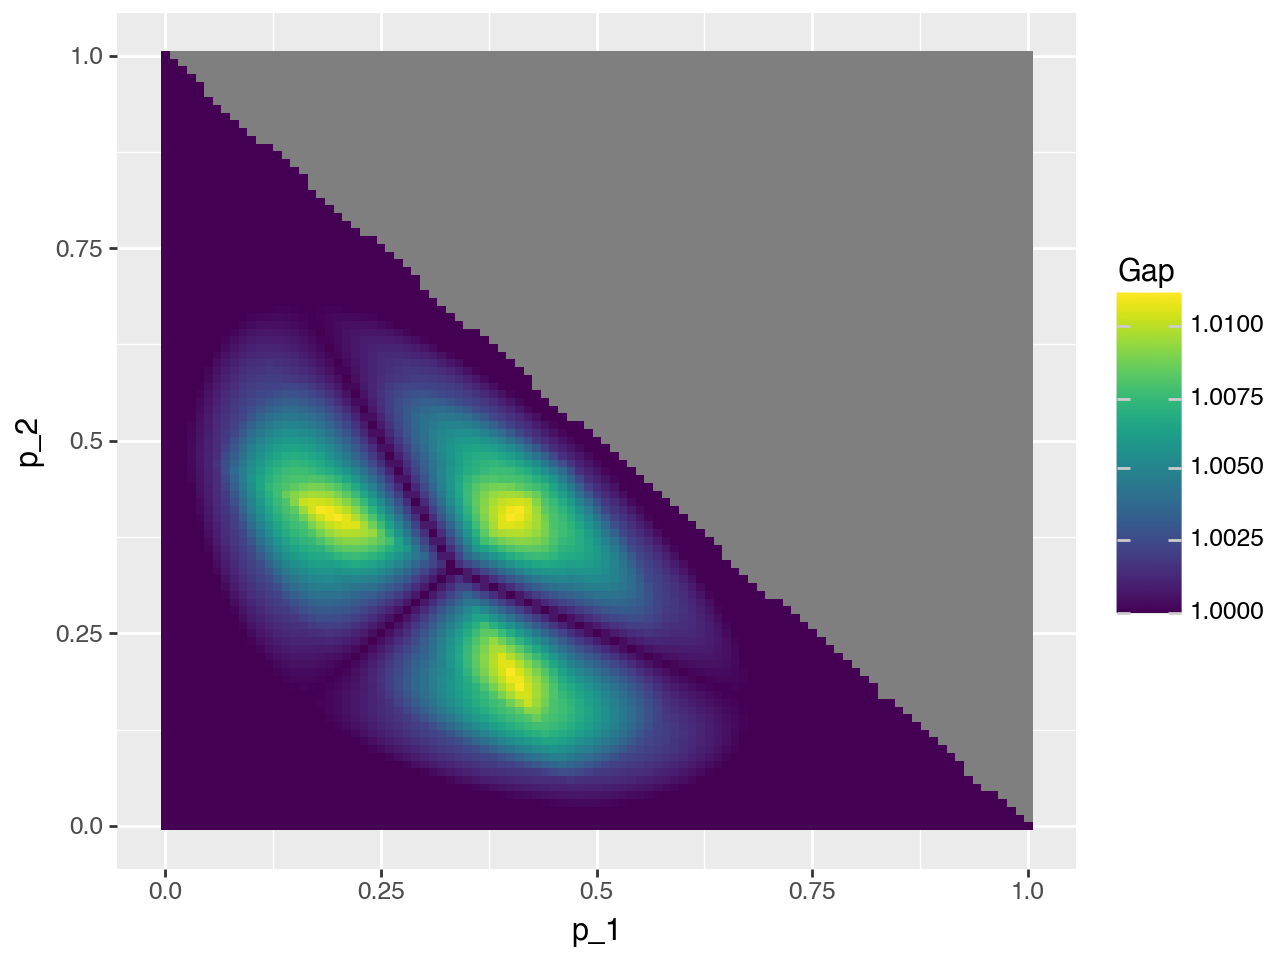

In [28]:
(
    ggplot(grid_df, aes('p_1','p_2')) 
    + geom_raster(aes(fill='Gap'),)
    + scale_x_continuous(labels=lambda x: [val * step for val in x])
    + scale_y_continuous(labels=lambda x: [val * step for val in x])
)

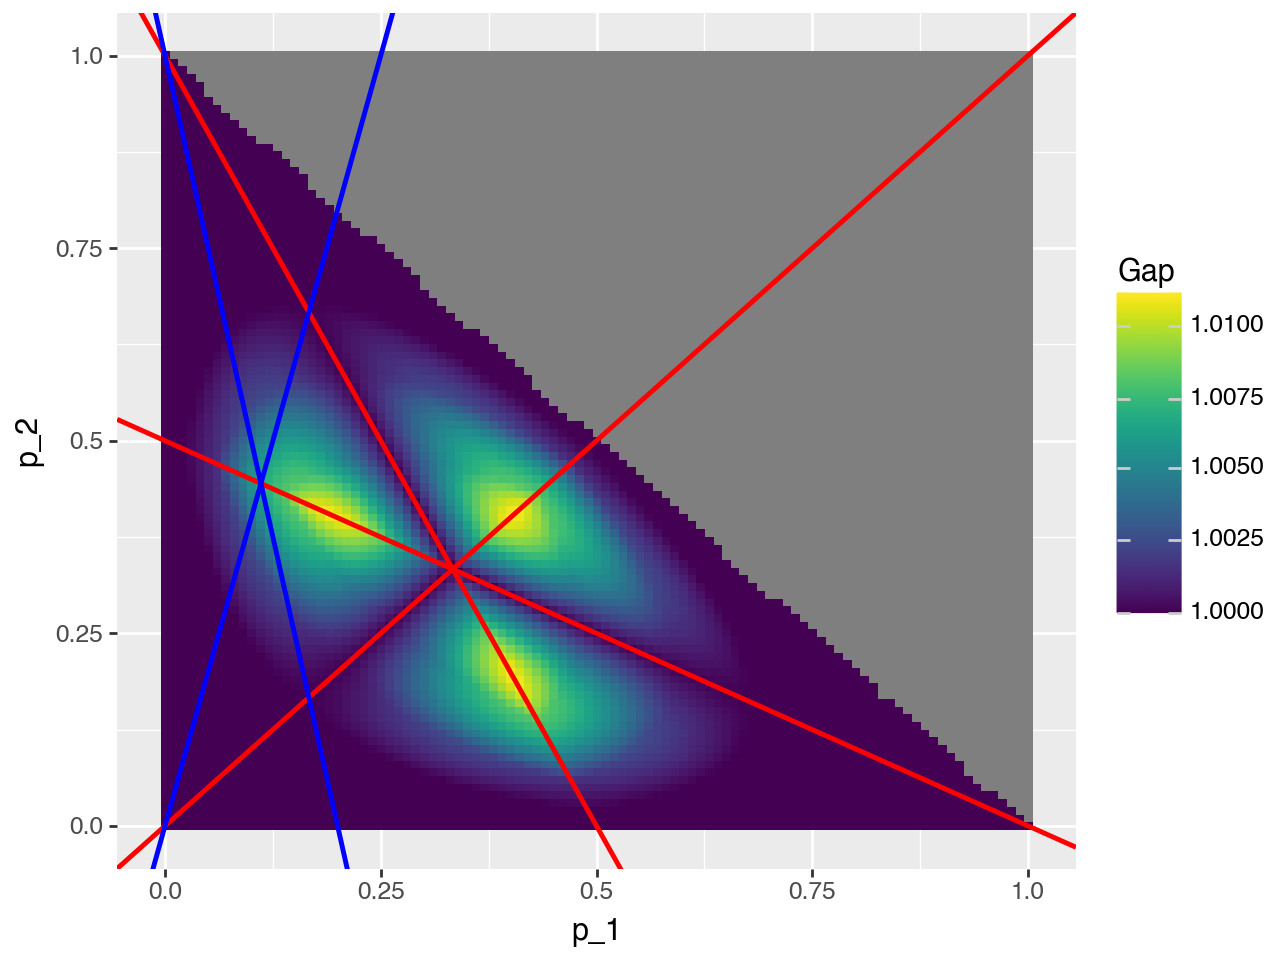

In [29]:
line_data = pd.DataFrame({'p_1': [0, 1], 'p_2': [1, 0]})
(
    ggplot(grid_df, aes('p_1','p_2')) 
    + geom_raster(aes(fill='Gap'),)
    + scale_x_continuous(labels=lambda x: [val * step for val in x])
    + scale_y_continuous(labels=lambda x: [val * step for val in x])
    + geom_abline(intercept=100, slope=-2, color='red', size=1)
    + geom_abline(intercept=0, slope=1, color='red', size=1)
    + geom_abline(intercept=50, slope=-.5, color='red', size=1)
    + geom_abline(intercept=100, slope=-5, color='blue', size=1)
    + geom_abline(intercept=0, slope=4, color='blue', size=1)
)

In [30]:
grid_df

,p_1,p_2,Gap
0,0,0,1.0
1,0,1,1.0
2,0,2,1.0
3,0,3,1.0
4,0,4,1.0
...,...,...,...
10196,100,96,NaN
10197,100,97,NaN
10198,100,98,NaN
10199,100,99,NaN


In [31]:
grid_df2 = grid_df.copy()
grid_df2['p_3'] = 100 - grid_df2.p_1 - grid_df2.p_2
grid_df2.p_1 = grid_df2.p_1 / 100
grid_df2.p_2 = grid_df2.p_2 / 100
grid_df2.p_3 = grid_df2.p_3 / 100
grid_df2 = grid_df2[grid_df2.p_3 > 0.001]

In [32]:
grid_df2

,p_1,p_2,Gap,p_3
0,0.00,0.00,1.0,1.00
1,0.00,0.01,1.0,0.99
2,0.00,0.02,1.0,0.98
3,0.00,0.03,1.0,0.97
4,0.00,0.04,1.0,0.96
...,...,...,...,...
9798,0.97,0.01,1.0,0.02
9799,0.97,0.02,1.0,0.01
9898,0.98,0.00,1.0,0.02
9899,0.98,0.01,1.0,0.01


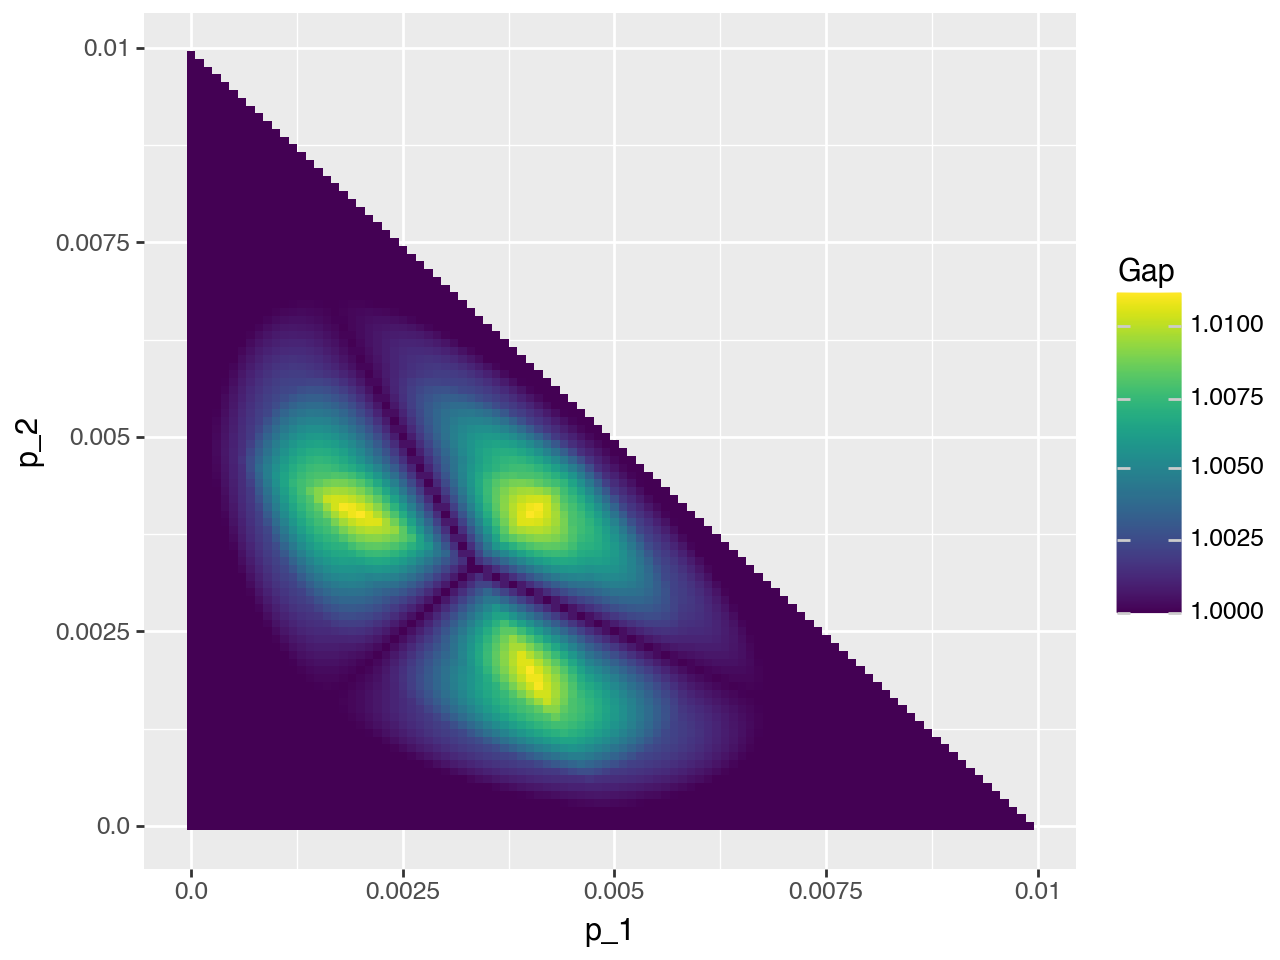

In [33]:
(
    ggplot(grid_df2, aes('p_1','p_2')) 
    + geom_raster(aes(fill='Gap'),)
    + scale_x_continuous(labels=lambda x: [val * step for val in x])
    + scale_y_continuous(labels=lambda x: [val * step for val in x])
)

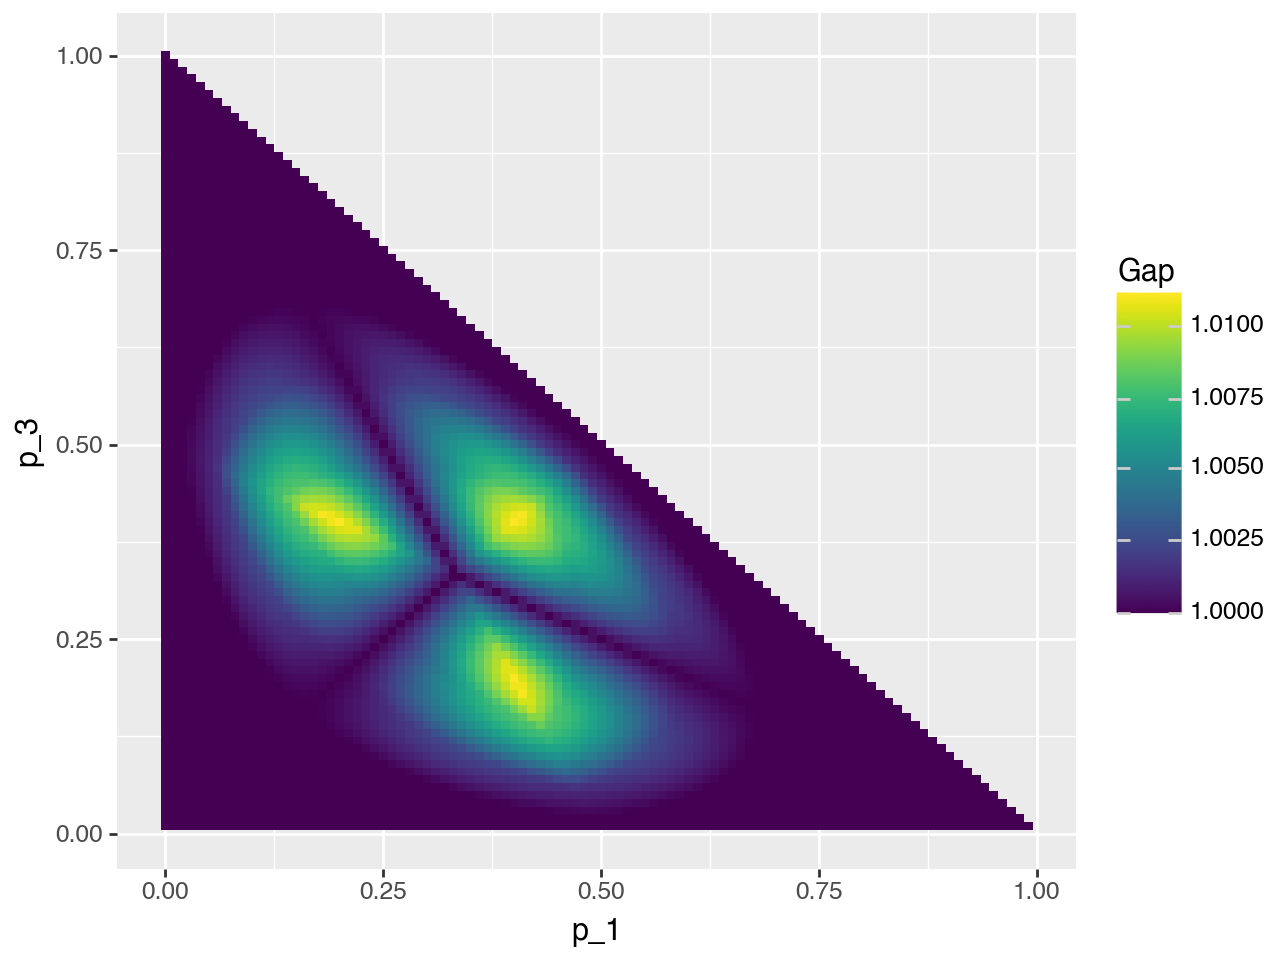

In [34]:
(
    ggplot(grid_df2, aes('p_1','p_3')) 
    + geom_raster(aes(fill='Gap'),)
    # + scale_x_continuous(labels=lambda x: [val * step for val in x])
    # + scale_y_continuous(labels=lambda x: [val * step for val in x])
)

In [35]:
grid_df2.p_3.unique()

array([1.  , 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.9 ,
       0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.8 , 0.79,
       0.78, 0.77, 0.76, 0.75, 0.74, 0.73, 0.72, 0.71, 0.7 , 0.69, 0.68,
       0.67, 0.66, 0.65, 0.64, 0.63, 0.62, 0.61, 0.6 , 0.59, 0.58, 0.57,
       0.56, 0.55, 0.54, 0.53, 0.52, 0.51, 0.5 , 0.49, 0.48, 0.47, 0.46,
       0.45, 0.44, 0.43, 0.42, 0.41, 0.4 , 0.39, 0.38, 0.37, 0.36, 0.35,
       0.34, 0.33, 0.32, 0.31, 0.3 , 0.29, 0.28, 0.27, 0.26, 0.25, 0.24,
       0.23, 0.22, 0.21, 0.2 , 0.19, 0.18, 0.17, 0.16, 0.15, 0.14, 0.13,
       0.12, 0.11, 0.1 , 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02,
       0.01])

In [36]:
grid_df2.p_1.dtype

dtype('float64')

In [37]:
norm_vec = [1,1,1]
e1 = [-np.sqrt(2)/2,np.sqrt(2)/2,0]
e2 = [-np.sqrt(3)/2,-np.sqrt(3)/2,np.sqrt(3)/2]

In [38]:
np.dot(e1, [0,0,1]), np.dot(e2, [0,0,1])

(np.float64(0.0), np.float64(0.8660254037844386))

In [39]:
grid_df2['proj_x'] = grid_df2[['p_1','p_2','p_3']].dot(e1)
grid_df2['proj_y'] = grid_df2[['p_1','p_2','p_3']].dot(e2)

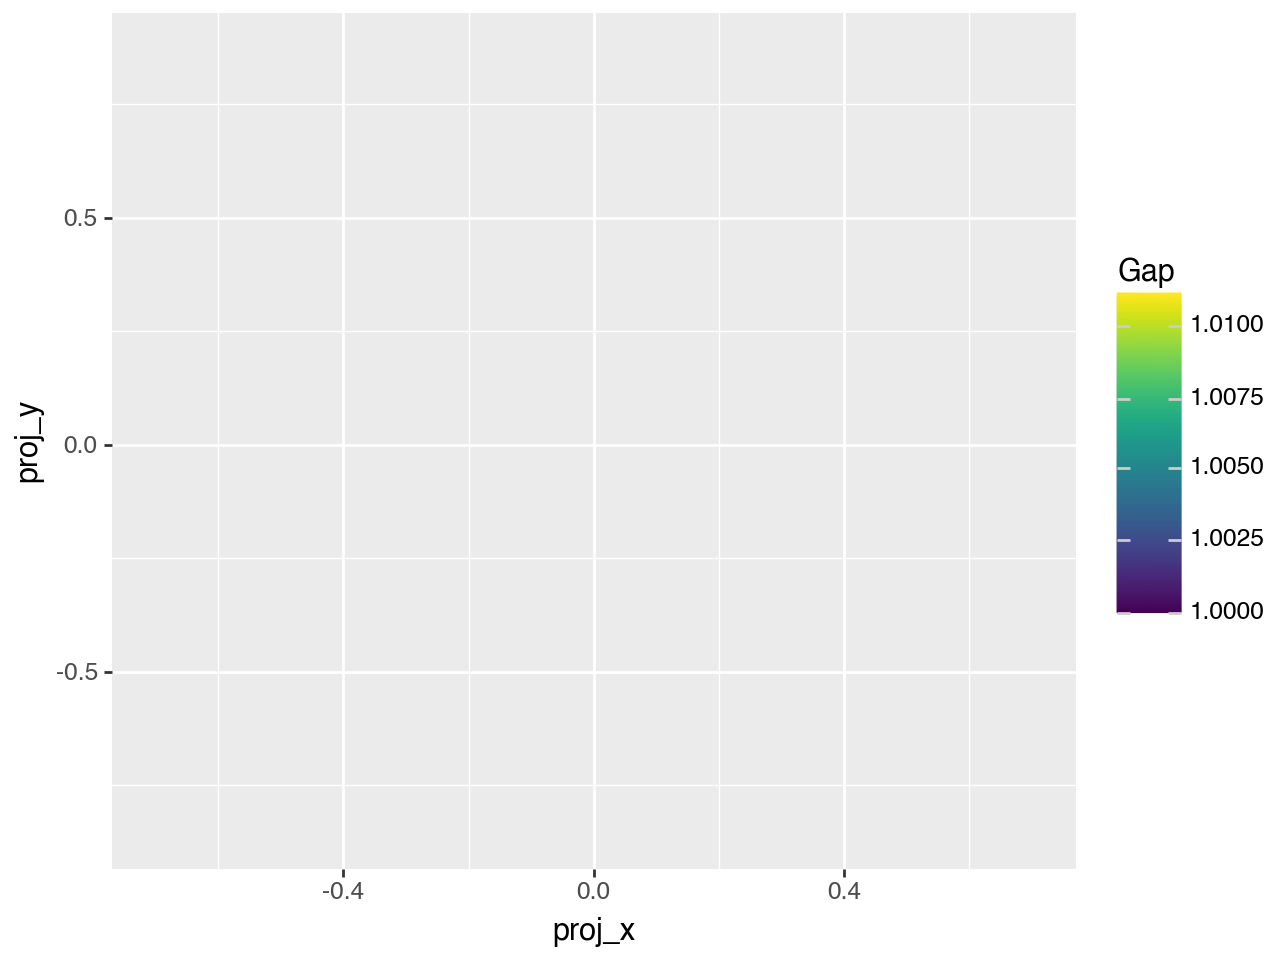

In [40]:
(
    ggplot(grid_df2, aes('proj_x','proj_y', fill='Gap')) 
    + geom_tile()
    # + scale_x_continuous(labels=lambda x: [val * step for val in x])
    # + scale_y_continuous(labels=lambda x: [val * step for val in x])
)

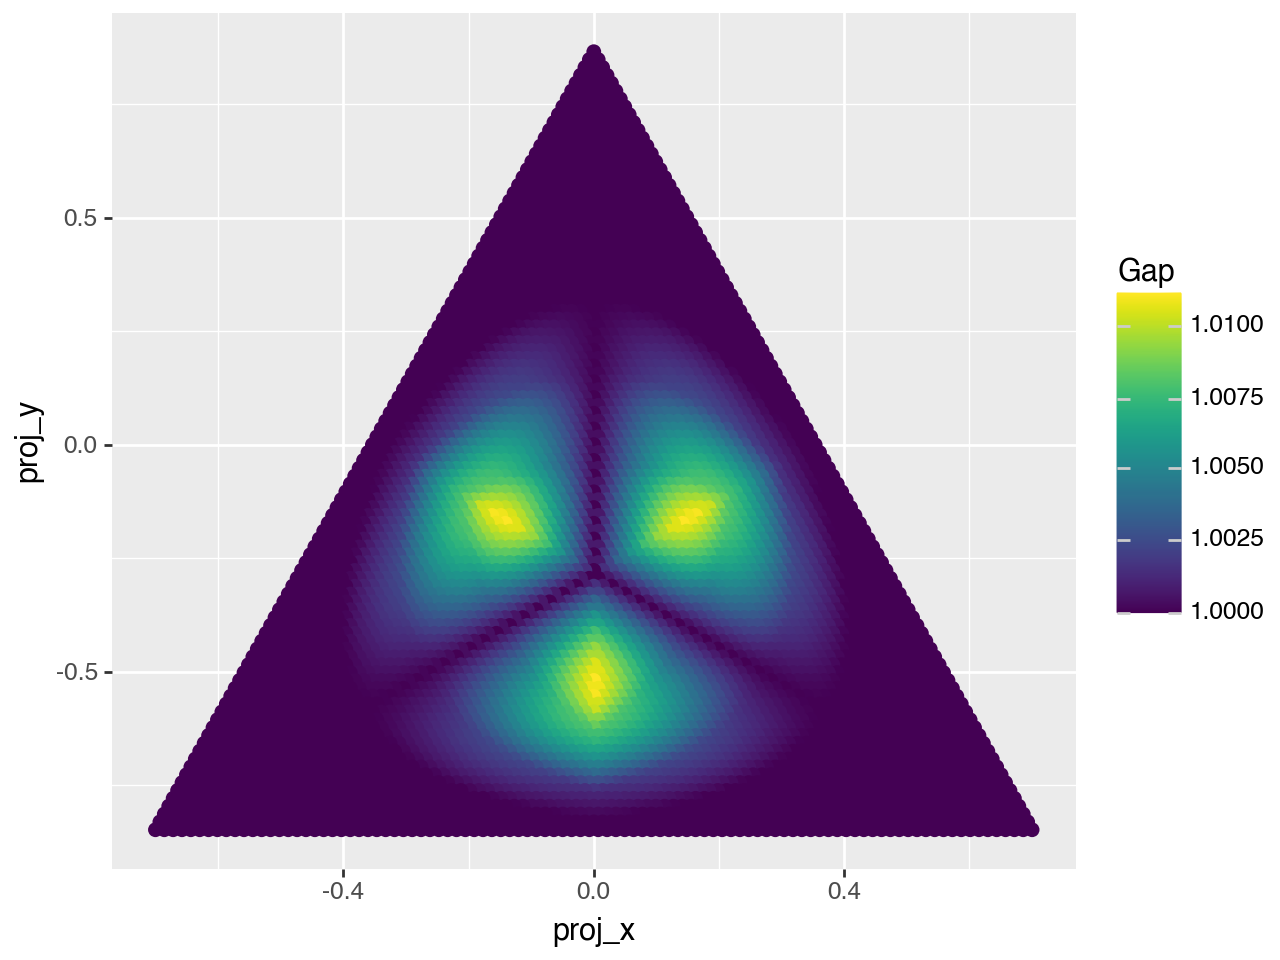

In [41]:
(
    ggplot(grid_df2, aes('proj_x','proj_y', fill='Gap')) 
    + geom_point(size=3, stroke=0)
    # + geom_vline(xintercept=0, color='red', size=1)
)

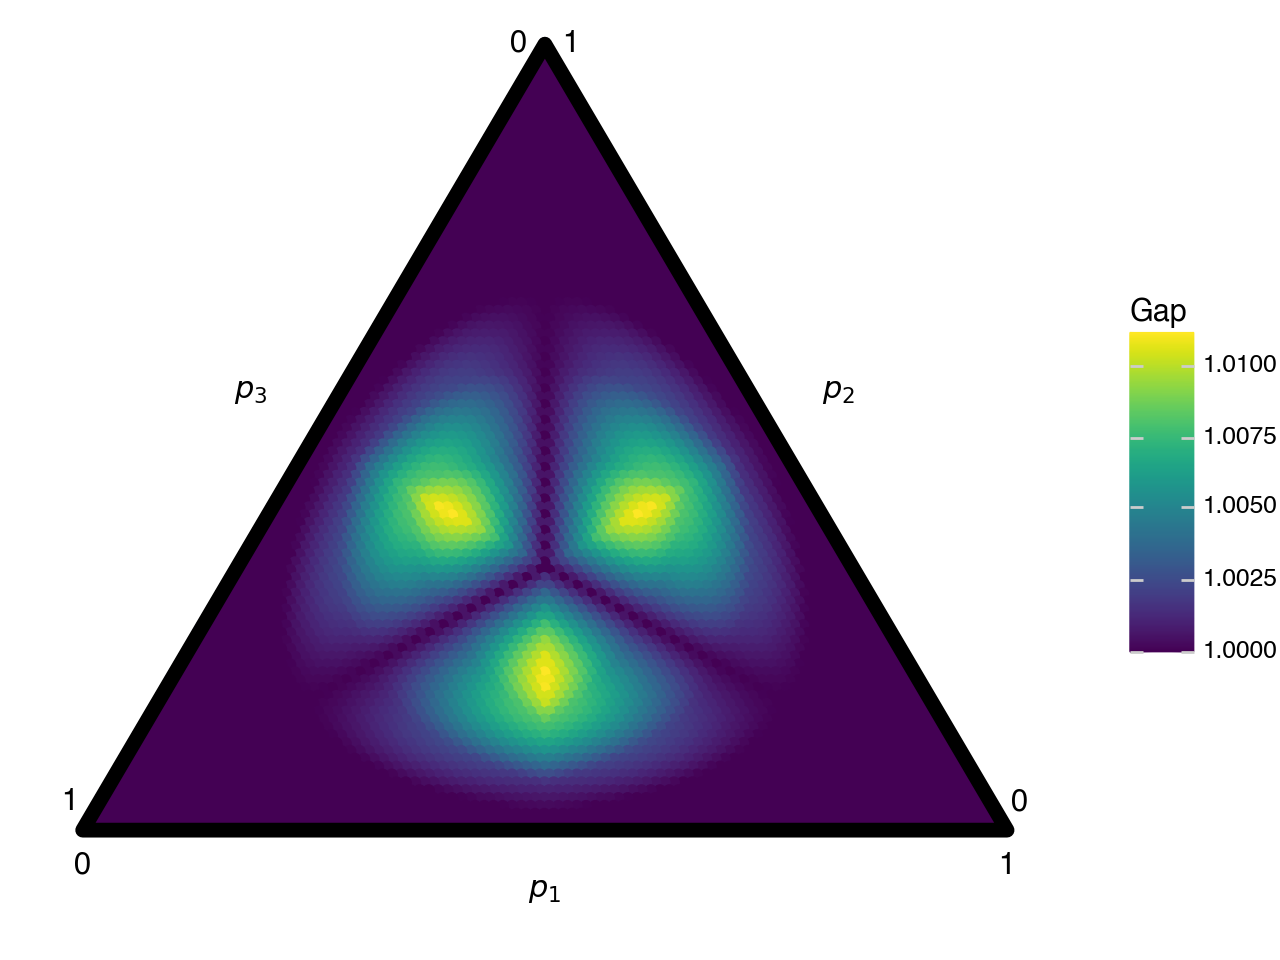

In [42]:
triangle = pd.DataFrame([[-np.sqrt(2)/2,-np.sqrt(3)/2],[np.sqrt(2)/2,-np.sqrt(3)/2],[0,np.sqrt(3)/2]], columns=['x','y'])
(
    ggplot(grid_df2, aes('proj_x','proj_y', fill='Gap')) 
    + geom_point(size=2.5, stroke=0)
    + theme_void()
    + geom_polygon(data=triangle, mapping=aes('x','y'), colour='black', fill=None, size=3)
    + plotnine.xlim(-np.sqrt(2)/2-.05,np.sqrt(2)/2+.05)
    + plotnine.ylim(-np.sqrt(2)/2-.35,np.sqrt(3)/2+.0)
    + plotnine.annotate('text', x=0, y=-1.0, label='$p_1$')
    + plotnine.annotate('text', x=0.45, y=0.1, label='$p_2$')
    + plotnine.annotate('text', x=-0.45, y=0.1, label='$p_3$')
    + plotnine.annotate('text', x=-np.sqrt(2)/2, y=-np.sqrt(3)/2 - 0.08, label='0')
    + plotnine.annotate('text', x=np.sqrt(2)/2, y=-np.sqrt(3)/2 - 0.08, label='1')
    + plotnine.annotate('text', x=np.sqrt(2)/2 + 0.02, y=-np.sqrt(3)/2 + 0.06, label='0')
    + plotnine.annotate('text', 0.04, y=np.sqrt(3)/2, label='1')
    + plotnine.annotate('text', -0.04, y=np.sqrt(3)/2, label='0')
    + plotnine.annotate('text', x=-np.sqrt(2)/2 - 0.02, y=-np.sqrt(3)/2 + 0.06, label='1')
    # + geom_vline(xintercept=0, color='red', size=1)
)

In [43]:
grid_df2[grid_df2.Gap == grid_df2.Gap.max()]

,p_1,p_2,Gap,p_3,proj_x,proj_y
4060,0.4,0.2,1.01115,0.4,-1.414214e-01,-0.173205
4080,0.4,0.4,1.01115,0.2,-1.760577e-17,-0.519615


In [44]:
max(list(grid_df2.Gap))

1.0111497061574861

In [45]:
def adaptivity_gap_poisson_log(n: int, k: int, p: list[float]):
    rv = poisson([n*i for i in p])
    max_nonadaptive = (0,(0,0,0))
    for order in permutations(range(3)):
        util = nonadaptive_util_poisson(rv, n, order, k)
        if util > max_nonadaptive[0]:
            max_nonadaptive = (util, order)
    # max_nonadaptive: float = max([nonadaptive_util_poisson(rv, n, order, k) for order in permutations(range(3))])
    max_adaptive = (0,0,(0,0,0))
    for order in permutations(range(3)):
        for t in range(k):
            util = adaptive_util_poisson(rv, n, order, k, t)
            if util > max_adaptive[0]:
                max_adaptive = (util, t, order)
    # max_adaptive: float = max([max([adaptive_util_poisson(rv, n, order, k, t) for t in range(k)]) for order in permutations(range(3))])
    return max_adaptive[0] / max_nonadaptive[0], max_adaptive, max_nonadaptive

In [46]:
adaptivity_gap_poisson_log(20, 16, [0.42, 0.42, 0.16])

(np.float64(1.0354984612541664),
 (np.float64(0.677321867288422), 8, (0, 2, 1)),
 (np.float64(0.6541022441192901), (0, 1, 2)))

In [47]:
adaptivity_gap_poisson_log(10, 8, [0.4, 0.4, 0.2])

(np.float64(1.0111497061574861),
 (np.float64(0.6719120020101719), 4, (0, 2, 1)),
 (np.float64(0.6645029889426897), (0, 1, 2)))